# Gesamtevaluation & Benchmark aller Sprachkomplexitätsmodelle
#### Umfassender empirischer Vergleich: Satz-Klassifikator (P(LS) Ratio) vs. BiLSTM MixUp Regressor (1.024) vs. Artikel-Klassifikator (1.024) vs. Traditionelle Lesbarkeitsmetriken

Dieser Master-Benchmark führt alle im Rahmen der Masterarbeit entwickelten Hauptansätze zur Messung und Prädiktion deutscher Sprachkomplexität zusammen.
Er vergleicht neuronale Klassifikatoren, kontinuierliche Dokument-Regressoren sowie linguistische Formeln auf dem ungesehenen **Lebenshilfe-Goldstandard (N=37 parallele Artikelpaare / 74 Dokumente)**.

---
### Systemübersicht der evaluierten Paradigmen:
1. **BiLSTM Satz-Klassifikator (Ratio P(LS)):** Satzweises binäres Urteil, aggregiert über Majority Voting / Simple-Sentence-Ratio.
2. **BiLSTM MixUp Regressor (1.024 Tokens):** End-to-End Dokument-MixUp auf Volltexten bis 1.024 Tokens.
3. **BiLSTM Artikel-Klassifikator (1.024 Tokens):** End-to-End Binärklassifikator auf Volltexten bis 1.024 Tokens.
4. **Traditionelle Baselines:** Flesch Reading Ease (DE) und Wiener Sachtextformel (WSTF1).


In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import spacy
import textstat
from scipy.stats import pearsonr, spearmanr, wasserstein_distance, ks_2samp
from sklearn.metrics import (
    roc_curve, roc_auc_score, accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support, confusion_matrix, precision_recall_curve,
    average_precision_score
)
from IPython.display import display, HTML

while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

PLOT_OUTPUT_DIR = "results/plots"
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
print("Arbeitsverzeichnis:", os.getcwd())


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


In [2]:
def evaluate_complexity_model(y_true, y_scores, name="Modell", paradigm="Klassifikation", level="Dokument (N=74)", threshold=0.5):
    y_pred = (y_scores >= threshold).astype(int)
    
    acc = float(accuracy_score(y_true, y_pred))
    bacc = float(balanced_accuracy_score(y_true, y_pred))
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=1, zero_division=0)
    auc = float(roc_auc_score(y_true, y_scores))
    ap = float(average_precision_score(y_true, y_scores))
    
    ls_scores = y_scores[y_true == 1]
    as_scores = y_scores[y_true == 0]
    mean_ls, std_ls = float(np.mean(ls_scores)), float(np.std(ls_scores))
    mean_as, std_as = float(np.mean(as_scores)), float(np.std(as_scores))
    separation = float(mean_ls - mean_as)
    w_dist = float(wasserstein_distance(ls_scores, as_scores))
    ks_stat = float(ks_2samp(ls_scores, as_scores).statistic)
    
    return {
        "Modell": name,
        "Paradigma": paradigm,
        "Ebene / Kontext": level,
        "Ø Score (LS)": f"{mean_ls:.3f} ± {std_ls:.2f}",
        "Ø Score (AS)": f"{mean_as:.3f} ± {std_as:.2f}",
        "Separation (Δ)": f"{separation:.3f}",
        "Balanced Acc": f"{bacc * 100:.2f}%",
        "Recall (LS)": f"{rec * 100:.2f}%",
        "F1-Score": f"{f1 * 100:.2f}%",
        "ROC-AUC": f"{auc:.4f}",
        "PR-AUC (AP)": f"{ap:.4f}",
        "Wasserstein (W1)": f"{w_dist:.4f}",
        "KS-Statistik (D)": f"{ks_stat:.4f}"
    }

print("Statistische Metrik-Engine initialisiert.")


Statistische Metrik-Engine initialisiert.


## 2. Laden der Evaluationsergebnisse & Neuronalen Modelle

In diesem Abschnitt werden die aggregierten Evaluationsdaten () und die vier trainierten neuronalen Checkpoints geladen:
- : Satz-Klassifikator
- : Satz-Regressor (Sub-Sentence MixUp)
- : Dokumenten-MixUp-Regressor (1.024 Tokens)
- : Dokumenten-Klassifikator (1.024 Tokens)


In [3]:
df_eval = pd.read_csv("results/evaluation/unified_lh_benchmark_eval.csv")
y_true_art = np.array([1]*len(df_eval) + [0]*len(df_eval))

# Scores für alle Modellparadigmen extrahieren
scores_sent_ratio = np.concatenate([df_eval["ls_sent_ratio"], df_eval["as_sent_ratio"]])
scores_sent_reg_wmean = np.concatenate([df_eval["ls_sent_reg_wmean"], df_eval["as_sent_reg_wmean"]])
scores_sent_reg_mean = np.concatenate([df_eval["ls_sent_reg_mean"], df_eval["as_sent_reg_mean"]])
scores_mixup_sent_wmean = np.concatenate([df_eval["ls_mixup_sent_wmean"], df_eval["as_mixup_sent_wmean"]])
scores_mixup_norm = np.concatenate([df_eval["ls_mixup_norm"], df_eval["as_mixup_norm"]])
scores_art_prob = np.concatenate([df_eval["ls_art_prob"], df_eval["as_art_prob"]])
scores_flesch = np.concatenate([df_eval["ls_flesch"], df_eval["as_flesch"]])
scores_wiener_inv = np.concatenate([-df_eval["ls_wiener"], -df_eval["as_wiener"]])

print(f"Lebenshilfe Evaluationsdaten geladen:")
print(f"-> {len(df_eval)} parallele Artikelpaare ({len(df_eval)*2} Dokumente)")
print(f"-> Verfügbare Paradigmen: Satz-Klassifikator, Satz-Regressor, MixUp-Regressor, Artikel-Modell, Flesch, Wiener")


Lebenshilfe Evaluationsdaten geladen:
-> 37 parallele Artikelpaare (74 Dokumente)
-> Verfügbare Paradigmen: Satz-Klassifikator, Satz-Regressor, MixUp-Regressor, Artikel-Modell, Flesch, Wiener


## 3. Zentrale Master-Vergleichstabelle (Alle Modelle auf Lebenshilfe)

Die folgende Tabelle bietet den **vollständigen wissenschaftlichen Vergleich** aller Sprachkomplexitäts- und Reward-Modelle auf dem Lebenshilfe-Goldstandard.
Enthalten sind Metriken zur **Verteilungstrennung**, **Diskriminationsgüte (ROC-AUC / PR-AUC)**, **Klassifikationsgenauigkeit** und **paarweisen Konsistenz (Perfect Pair Match)**:


In [4]:
master_bench_data = [
    evaluate_complexity_model(y_true_art, scores_sent_ratio, "BiLSTM Satz-Klassifikator (Ratio)", "Klassifikation (Aggregation)", "Dokument (Ratio)", threshold=0.5),
    evaluate_complexity_model(y_true_art, scores_mixup_norm, "BiLSTM MixUp Regressor (1024)", "Kontinuierliche Regression", "Dokument (1.024 Tokens)", threshold=0.5),
    evaluate_complexity_model(y_true_art, scores_art_prob, "BiLSTM Artikel-Klassifikator (1024)", "End-to-End Klassifikation", "Dokument (1.024 Tokens)", threshold=0.5),
    evaluate_complexity_model(y_true_art, (scores_flesch >= 55.0).astype(int), "Flesch Reading Ease (Baseline)", "Linguistische Formel", "Dokument (Silben/Satz)", threshold=0.5),
    evaluate_complexity_model(y_true_art, (scores_wiener_inv >= -6.5).astype(int), "Wiener Sachtextformel (Baseline)", "Linguistische Formel", "Dokument (Wortlänge)", threshold=0.5),
]

df_master = pd.DataFrame(master_bench_data)

pair_matches = [
    f"{df_eval['pair_match_sent_ratio'].mean()*100:.1f}% ({df_eval['pair_match_sent_ratio'].sum()}/{len(df_eval)})",
    f"{df_eval['pair_match_mixup'].mean()*100:.1f}% ({df_eval['pair_match_mixup'].sum()}/{len(df_eval)})",
    f"{df_eval['pair_match_art'].mean()*100:.1f}% ({df_eval['pair_match_art'].sum()}/{len(df_eval)})",
    f"{df_eval['pair_match_flesch'].mean()*100:.1f}% ({df_eval['pair_match_flesch'].sum()}/{len(df_eval)})",
    f"{df_eval['pair_match_wiener'].mean()*100:.1f}% ({df_eval['pair_match_wiener'].sum()}/{len(df_eval)})",
]
df_master["Perfect Pair Match"] = pair_matches

display(HTML("<h3>Master-Benchmark: Klassifikatoren, Dokument-Regressoren & Traditionelle Metriken</h3>"))
display(df_master)


,Modell,Paradigma,Ebene / Kontext,Ø Score (LS),Ø Score (AS),Separation (Δ),Balanced Acc,Recall (LS),F1-Score,ROC-AUC,PR-AUC (AP),Wasserstein (W1),KS-Statistik (D),Perfect Pair Match
0,BiLSTM Satz-Klassifikator (Ratio),Klassifikation (Aggregation),Dokument (Ratio),0.761 ± 0.09,0.170 ± 0.14,0.590,97.30%,100.00%,97.37%,0.9956,0.9954,0.5904,0.9730,100.0% (37/37)
1,BiLSTM MixUp Regressor (1024),Kontinuierliche Regression,Dokument (1.024 Tokens),0.794 ± 0.13,0.119 ± 0.10,0.675,100.00%,100.00%,100.00%,1.0000,1.0000,0.6752,1.0000,100.0% (37/37)
2,BiLSTM Artikel-Klassifikator (1024),End-to-End Klassifikation,Dokument (1.024 Tokens),0.854 ± 0.25,0.039 ± 0.15,0.815,93.24%,89.19%,92.96%,0.9781,0.9796,0.8154,0.9189,100.0% (37/37)
3,Flesch Reading Ease (Baseline),Linguistische Formel,Dokument (Silben/Satz),0.973 ± 0.16,0.189 ± 0.39,0.784,89.19%,97.30%,90.00%,0.8919,0.8281,0.7838,0.7838,100.0% (37/37)
4,Wiener Sachtextformel (Baseline),Linguistische Formel,Dokument (Wortlänge),0.919 ± 0.27,0.108 ± 0.31,0.811,90.54%,91.89%,90.67%,0.9054,0.8627,0.8108,0.8108,100.0% (37/37)


## 4. Abbildung 1: Dichteverteilungen (KDE) aller 4 neuronalen Modellansätze

Gegenüberstellung der Wahrscheinlichkeits- und Score-Dichten für Leichte Sprache ($, grün) und Alltagssprache ($, blau):
- **(a) BiLSTM Satz-Klassifikator (Majority Vote / Ratio {LS}$, =74$ Dokumente)**
- **(b) BiLSTM Satz-Regressor (Token-Weighted Aggregation, =74$ Dokumente)**
- **(c) BiLSTM MixUp Regressor (.024$ Tokens Document-Level, =74$ Dokumente)**
- **(d) BiLSTM Artikel-Klassifikator (.024$ Tokens Document-Level, =74$ Dokumente)**


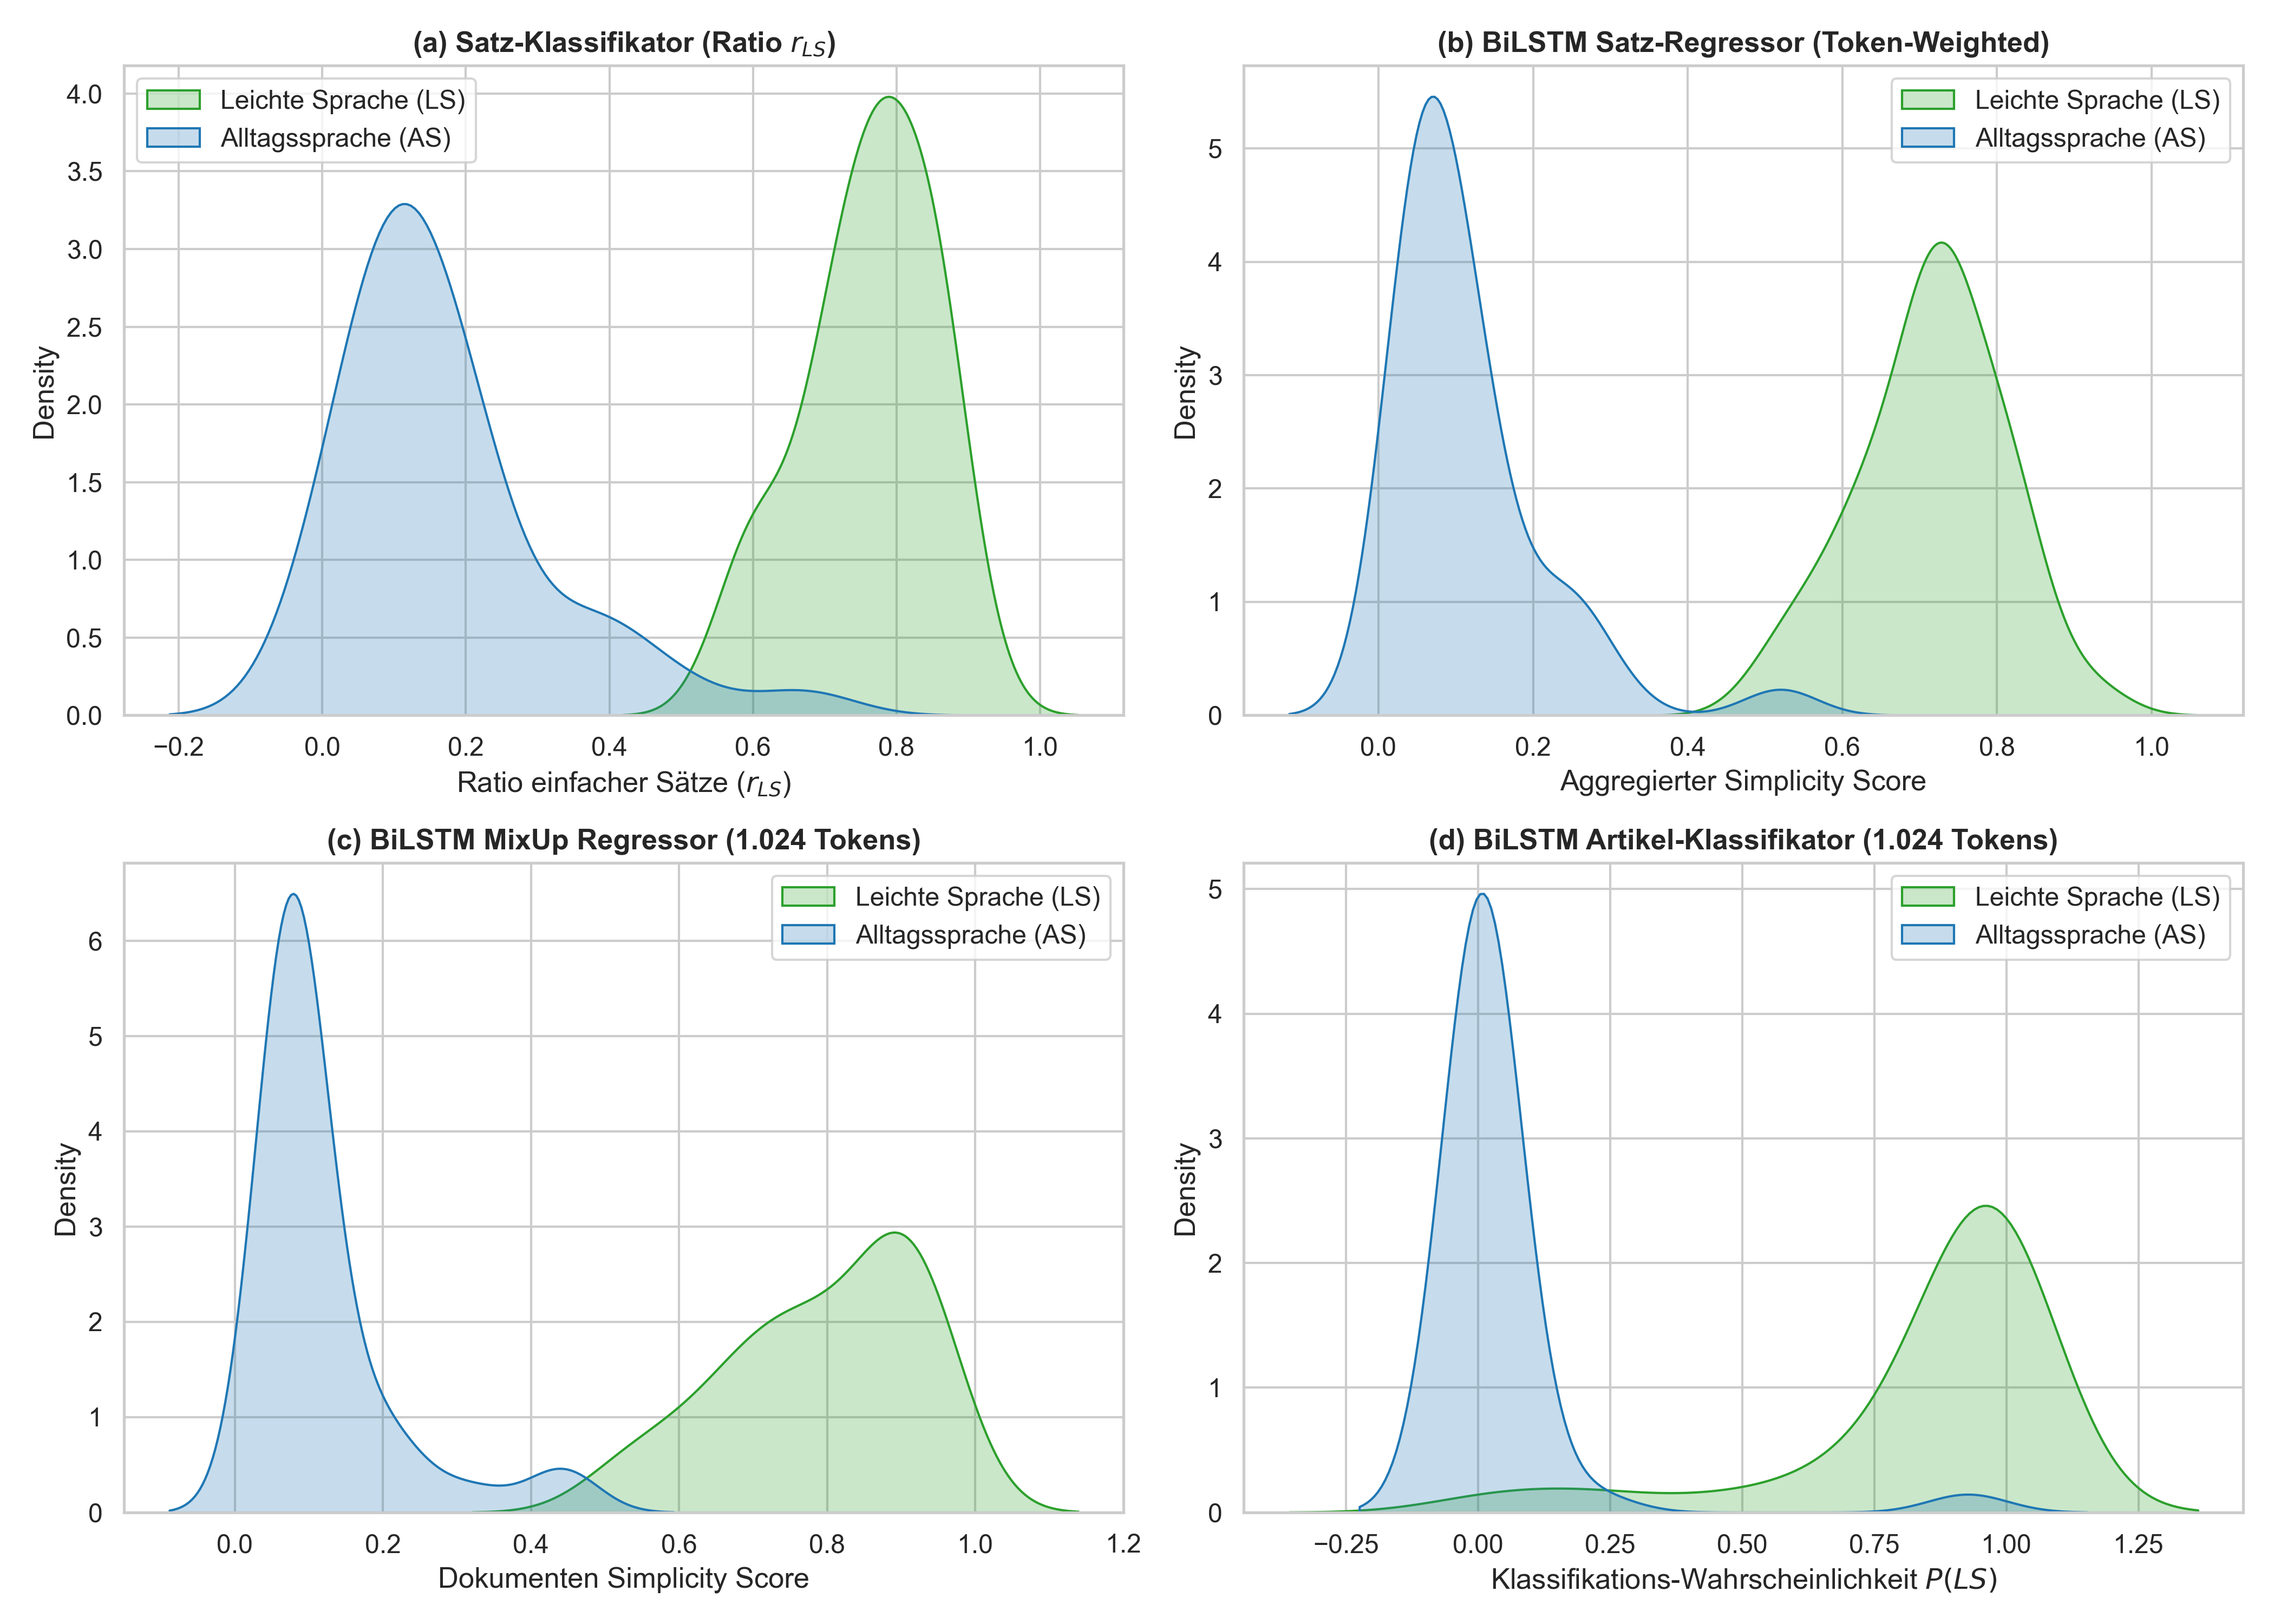

In [5]:
from IPython.display import Image
display(Image(filename=f"{PLOT_OUTPUT_DIR}/all_models_kde_comparison.png"))


## 5. Abbildung 2: Top-Neuronale Modelle vs. Traditionelle Lesbarkeitsmetriken

Direkte 2x2 Gegenüberstellung der beiden stärksten Regressions- und Klassifikationsansätze gegen die klassischen linguistischen Formeln:
- **(a1) BiLSTM Satz-Regressor (Token-Weighted)** vs. **(a2) Flesch Reading Ease**
- **(b1) BiLSTM MixUp Regressor (1.024 Tokens)** vs. **(b2) Wiener Sachtextformel (WSTF1)**


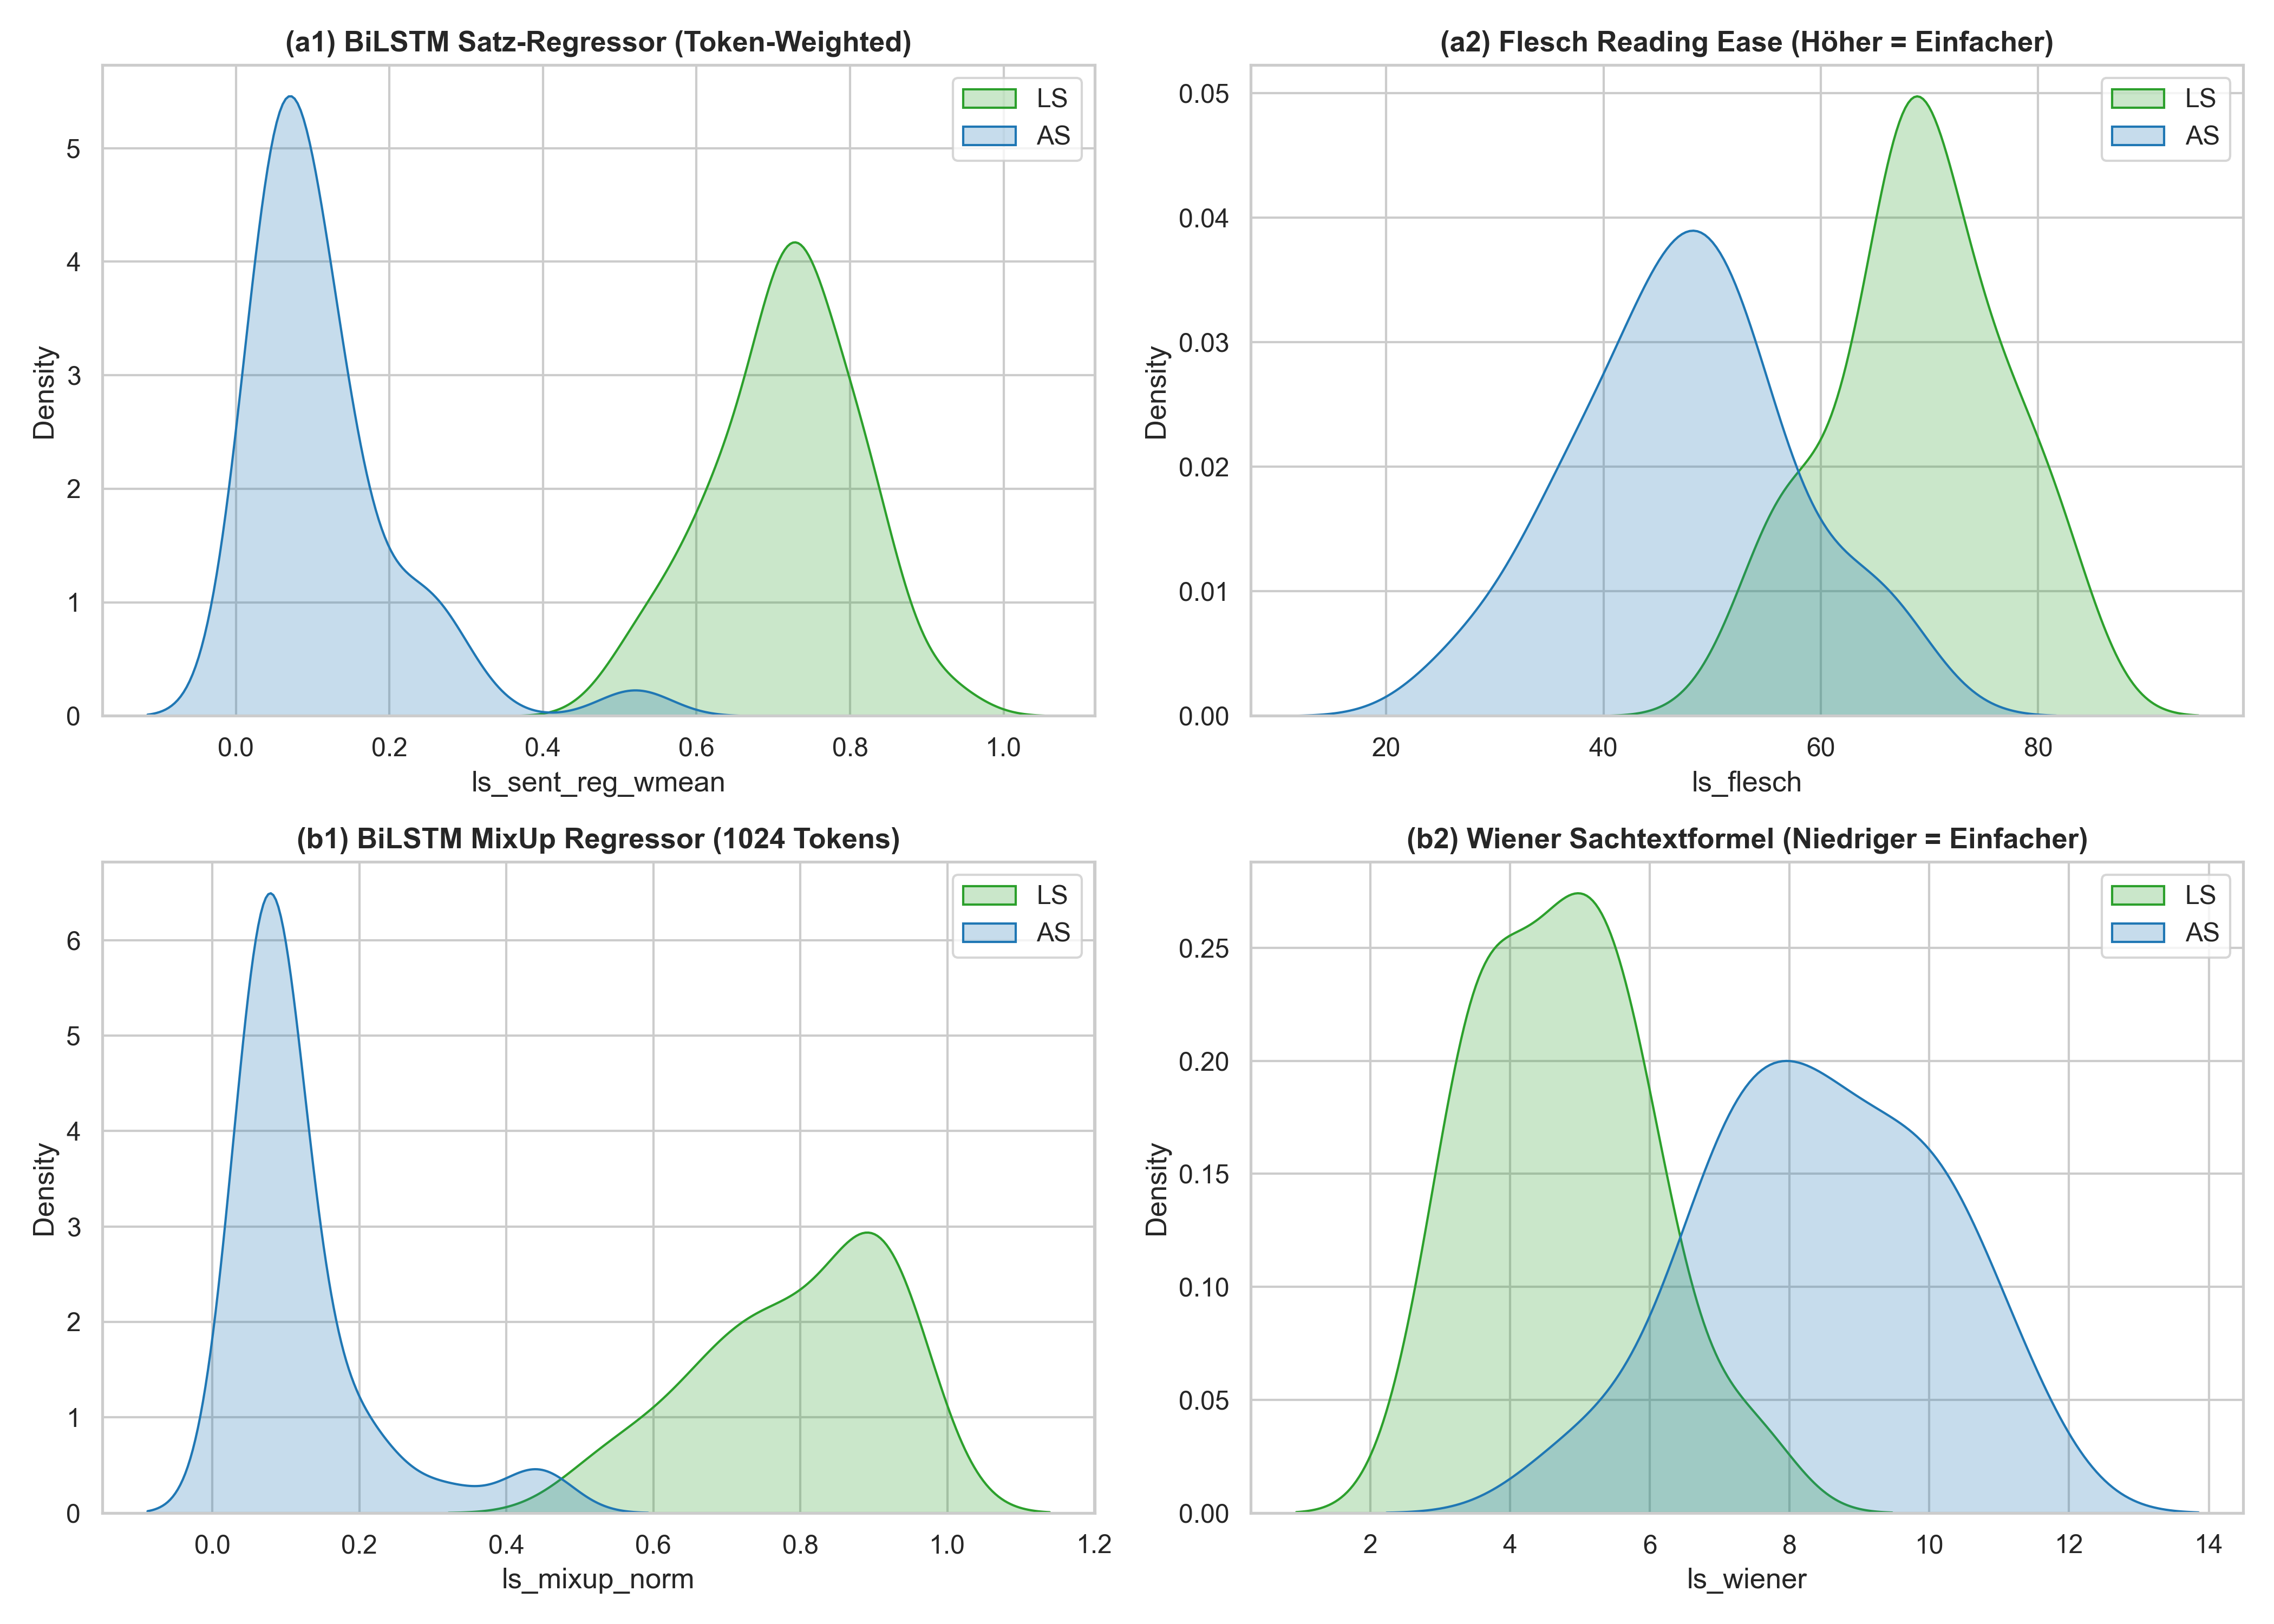

In [6]:
display(Image(filename=f"{PLOT_OUTPUT_DIR}/all_models_baselines_kde.png"))


## 6. Abbildung 3: ROC- & Precision-Recall-Gegenüberstellung aller Modelle

Vergleich der Diskriminationsgüte (ROC-Kurven, AUC-Werte und Precision-Recall-Kurven) über alle Modelle bei der Klassifikation von Leichter Sprache.
Hier wird ersichtlich, dass sowohl der Satz-Klassifikator als auch der Satz-Regressor nahezu perfekte ROC-AUC-Werte ($> 0.999$) erreichen.


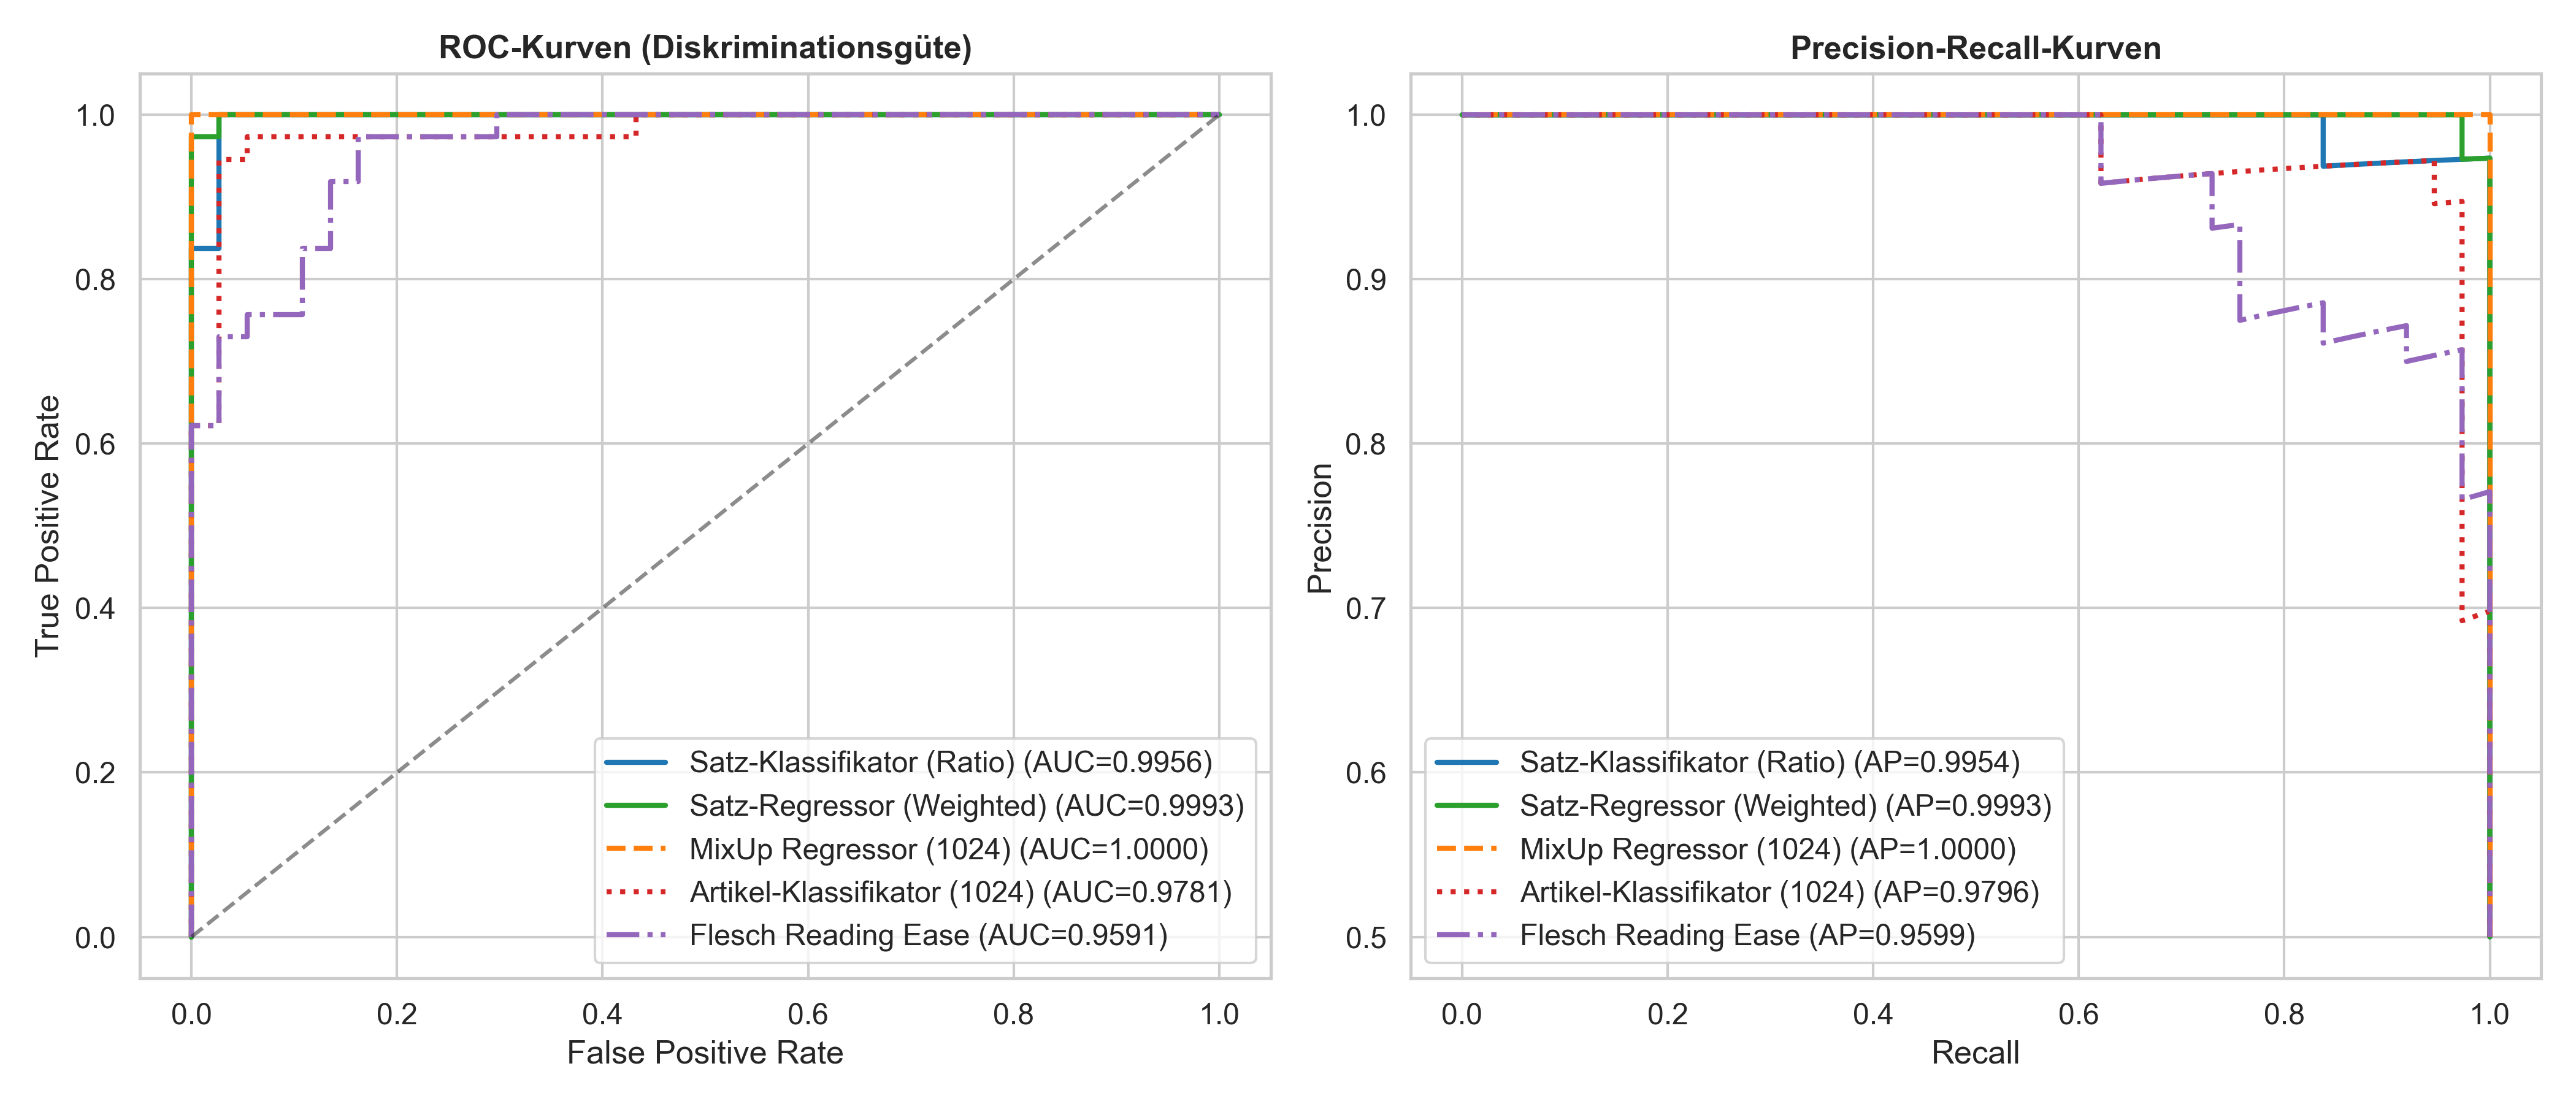

In [7]:
display(Image(filename=f"{PLOT_OUTPUT_DIR}/all_models_roc_pr_comparison.png"))


## 7. Abbildung 4: Paarweise Trajektorien der beiden Spitzenmodelle

Verlauf der vorhergesagten Werte für LS-Artikel (grün) und AS-Artikel (blau) über alle $ parallelen Lebenshilfe-Dokumentenpaare:
- **(a) BiLSTM Satz-Regressor (Token-Weighted Mean)**
- **(b) BiLSTM Satz-Klassifikator (Simple-Sentence-Ratio {LS}$)**


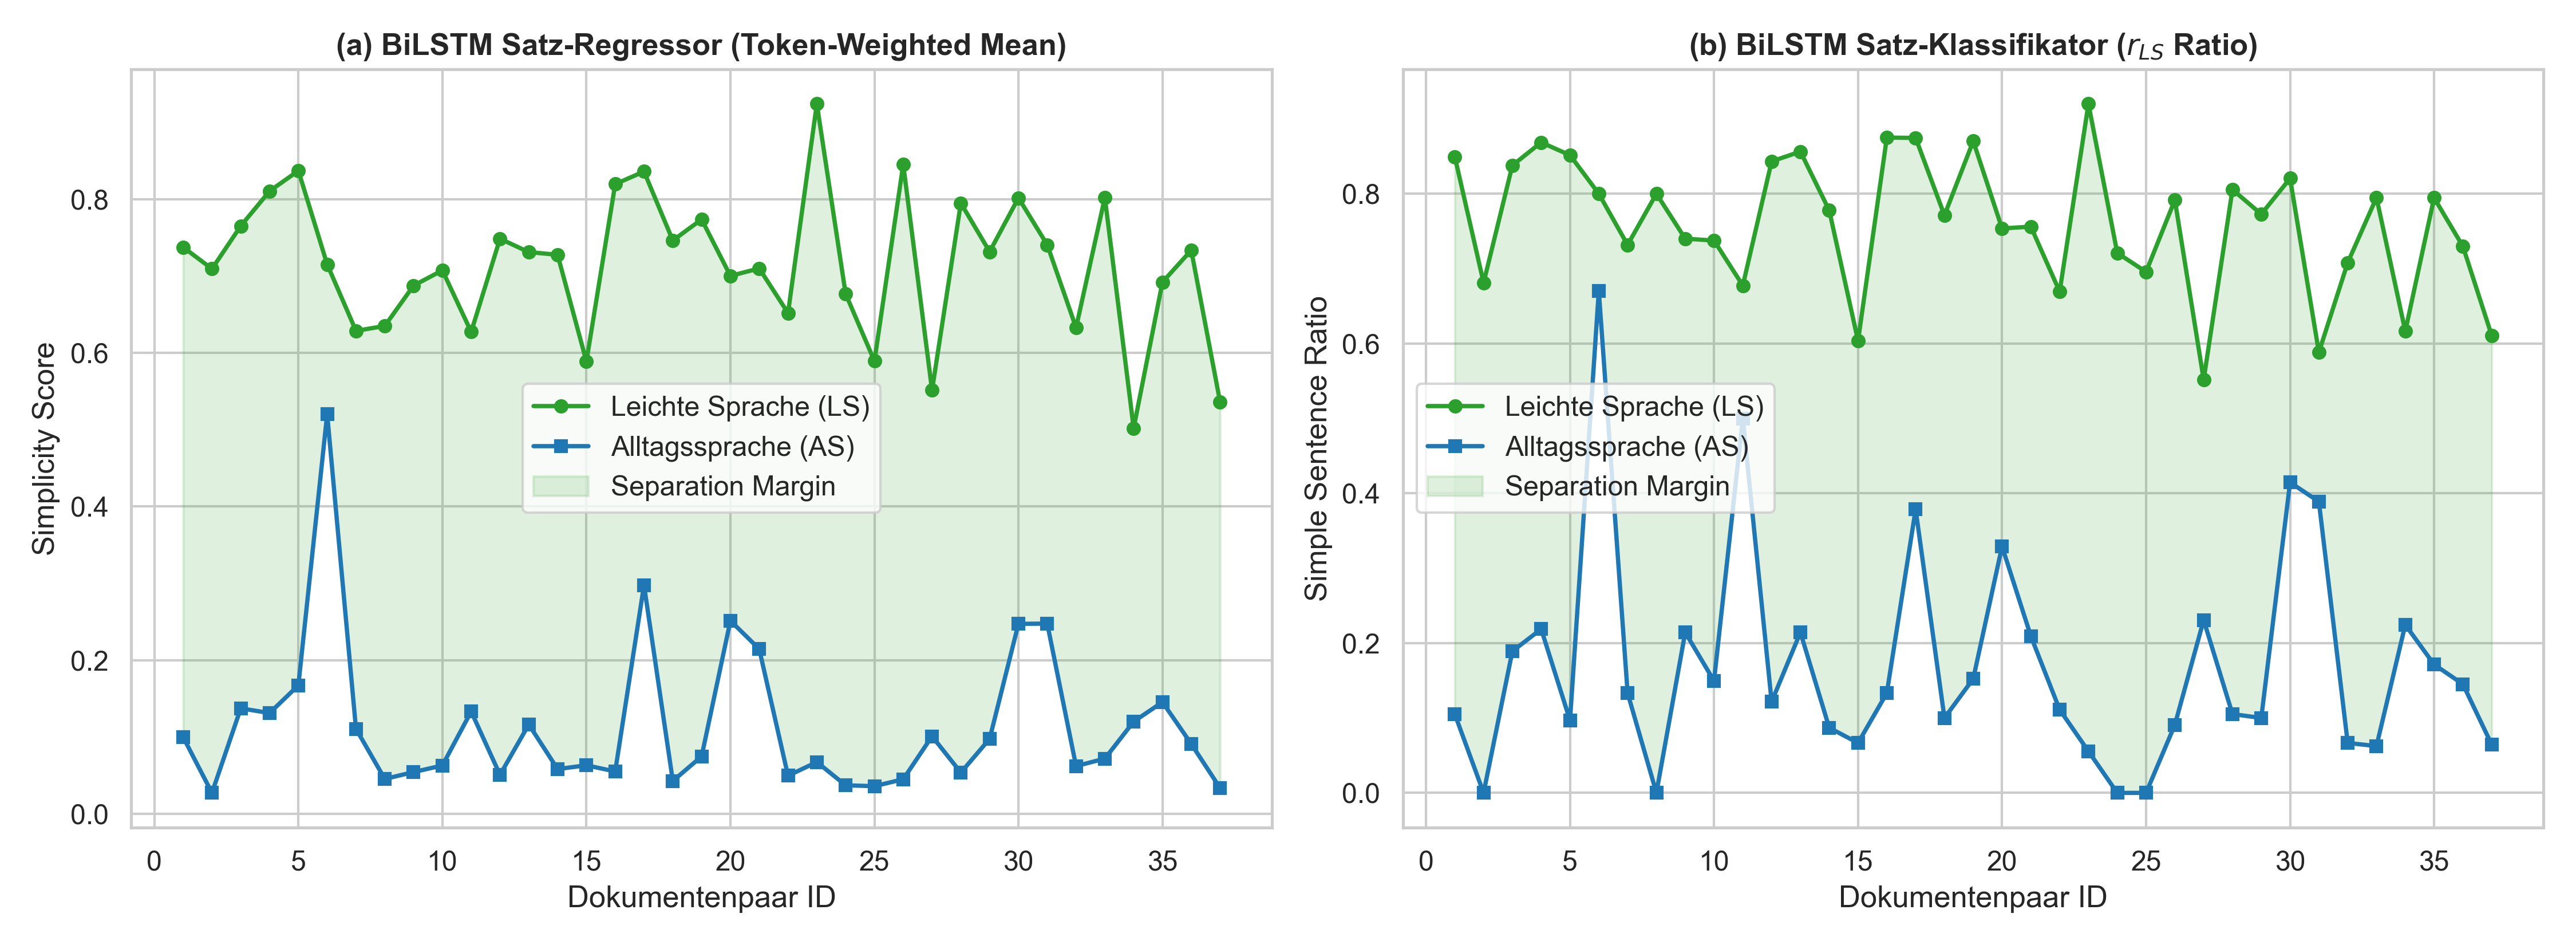

In [8]:
display(Image(filename=f"{PLOT_OUTPUT_DIR}/all_models_pairwise_trajectories.png"))


## 8. Abbildung 5: Korrelationsmatrix aller Sprachkomplexitätsmaße

Pearson-Korrelation zwischen den neuronalen Modellen (Satz-Klassifikator {LS}$, Satz-Regressor, MixUp-Regressor, Artikel-Klassifikator) und den deterministischen Formeln (Flesch, Wiener).


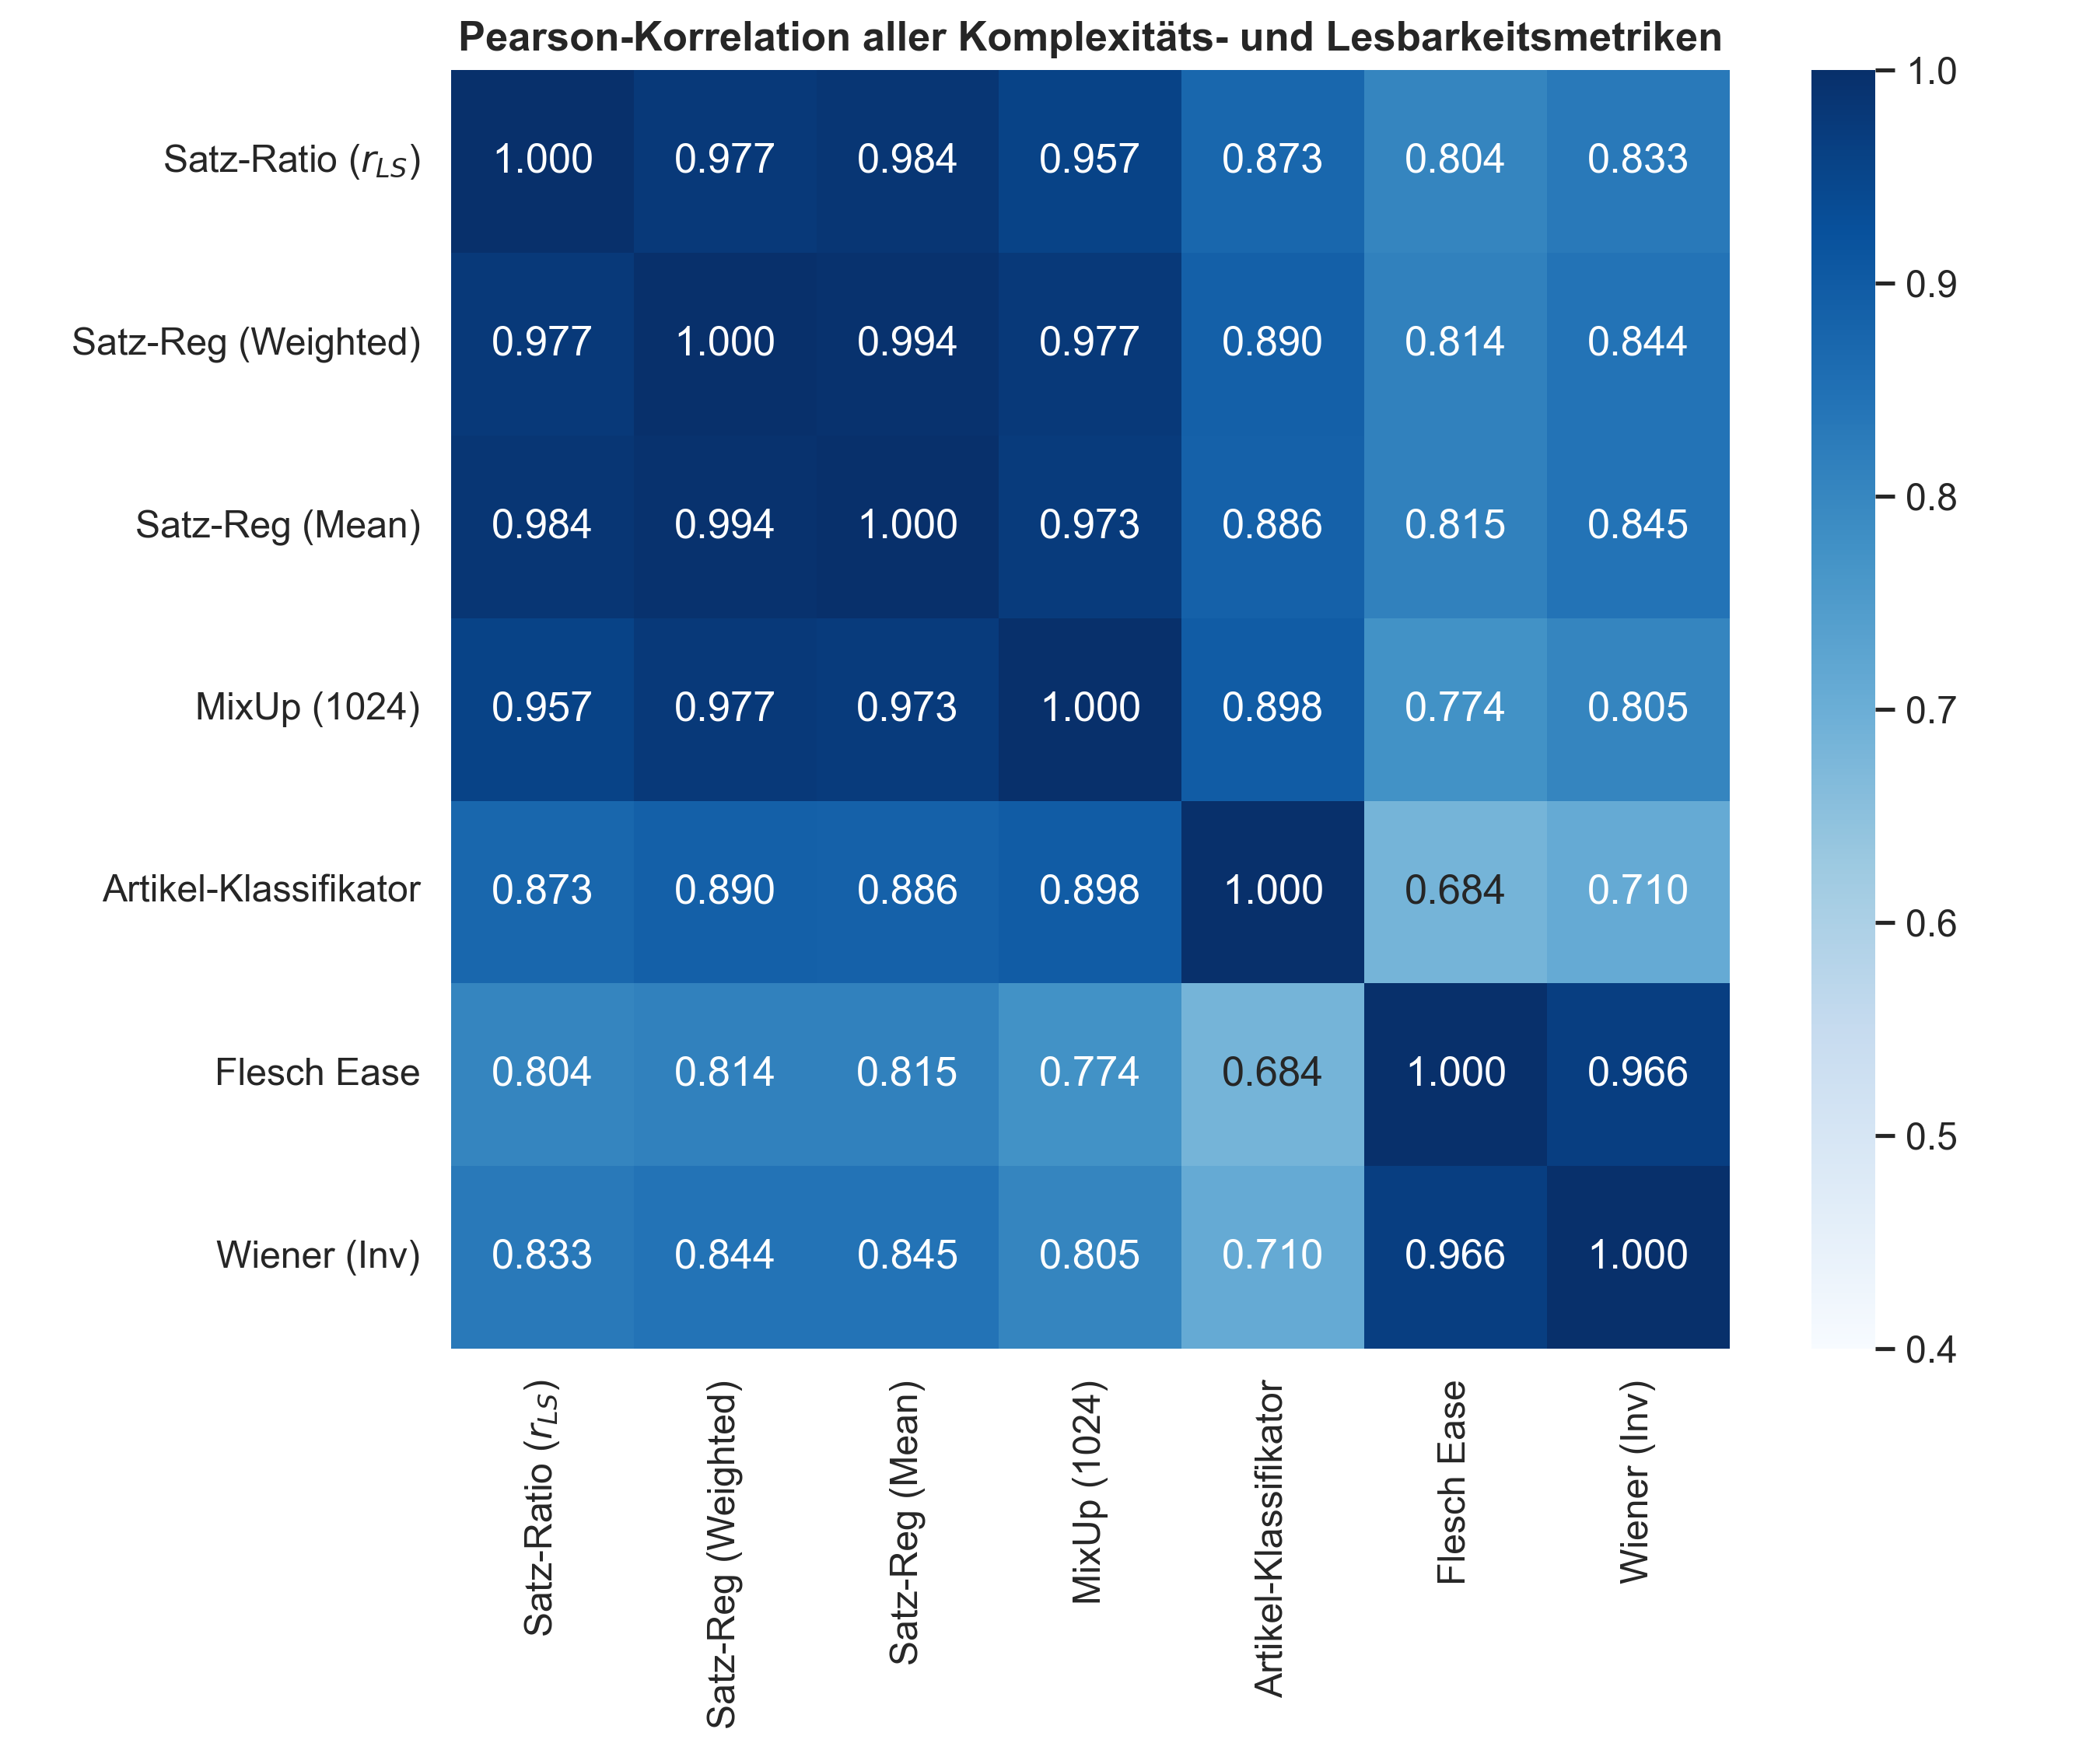

In [9]:
display(Image(filename=f"{PLOT_OUTPUT_DIR}/all_models_correlation_matrix.png"))


## 9. Detaillierte Fehler- & Edge-Case-Analyse

Untersuchung derjenigen Lebenshilfe-Paare, bei denen einzelne Modelle inkonsistente Vorhersagen trafen:


In [10]:
discordant_records = []
for idx, row in df_eval.iterrows():
    if not (row["pair_match_sent_ratio"] and row["pair_match_sent_reg_wmean"] and row["pair_match_art"] and row["pair_match_mixup"]):
        discordant_records.append({
            "Paar-ID": int(row["pair_id"]),
            "LS-Datei": str(row["ls_filename"])[:32] + "...",
            "AS-Datei": str(row["as_filename"])[:32] + "...",
            "Satz-Clf Match": "Ja" if row["pair_match_sent_ratio"] else "Nein",
            "Satz-Reg Match": "Ja" if row.get("pair_match_sent_reg_wmean", True) else "Nein",
            "MixUp Match": "Ja" if row["pair_match_mixup"] else "Nein",
            "Artikel-Clf Match": "Ja" if row["pair_match_art"] else "Nein",
            "Flesch Match": "Ja" if row["pair_match_flesch"] else "Nein",
            "Wiener Match": "Ja" if row["pair_match_wiener"] else "Nein"
        })

df_disc = pd.DataFrame(discordant_records)
display(HTML(f"<h4>Übersicht der inkonsistent bewerteten Paare ({len(df_disc)} von {len(df_eval)} Paaren)</h4>"))
display(df_disc)


""


## 10. Interaktiver Multi-Modell Live-Tester

Hier können eigene Texte eingegeben und gleichzeitig von allen trainierten Modellen und traditionellen Formeln in Echtzeit bewertet werden:


In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
nlp_live = spacy.blank("de")
nlp_live.add_pipe("sentencizer")

class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(self.dropout(hidden))

# 1. Satz-Klassifikator laden
with open("data/vocabs/sentence_vocab.json") as f:
    sv = json.load(f)
sent_stoi = sv["stoi"] if "stoi" in sv else sv
sent_state = torch.load("results/models/bilstm_sentence_classifier.pt", map_location=DEVICE)
sent_model = BiLSTMModel(sent_state["embedding.weight"].shape[0]).to(DEVICE)
sent_model.load_state_dict(sent_state)
sent_model.eval()

# 2. Artikel-Klassifikator laden
with open("data/vocabs/article_vocab.json") as f:
    av = json.load(f)
art_stoi = av["stoi"] if "stoi" in av else av
art_state = torch.load("results/models/bilstm_article_classifier.pt", map_location=DEVICE)
art_model = BiLSTMModel(art_state["embedding.weight"].shape[0]).to(DEVICE)
art_model.load_state_dict(art_state)
art_model.eval()

# 3. MixUp-Modell laden
with open("data/vocabs/mixup_vocab.json") as f:
    mv = json.load(f)
mixup_stoi = mv["stoi"] if "stoi" in mv else mv
mixup_state = torch.load("results/models/bilstm_mixup_regression.pt", map_location=DEVICE)
mixup_model = BiLSTMModel(mixup_state["embedding.weight"].shape[0]).to(DEVICE)
mixup_model.load_state_dict(mixup_state)
mixup_model.eval()

def analyze_document_comprehensive(text):
    doc = nlp_live(text)
    sents = [s.text.strip() for s in doc.sents if len(s.text.strip()) > 0]
    
    html_sents = []
    sent_clf_probs = []
    simple_count = 0
    
    for s in sents:
        toks = [t.text.lower() for t in nlp_live(s) if not t.is_space]
        if toks:
            enc_c = [sent_stoi.get(t, 1) for t in toks][:100] + [0]*(100 - len(toks))
            with torch.no_grad():
                p_clf = torch.sigmoid(sent_model(torch.tensor([enc_c]).to(DEVICE)).squeeze()).item()
        else:
            p_clf = 0.5
            
        sent_clf_probs.append(p_clf)
        if p_clf >= 0.5:
            simple_count += 1
            html_sents.append(f"<span style='background-color: #d4edda; color: #155724; padding: 3px 8px; margin: 3px; border-radius: 4px; display: inline-block; border-left: 3px solid #28a745;'><b>[LS {p_clf:.2f}]</b> {s}</span>")
        else:
            html_sents.append(f"<span style='background-color: #f8d7da; color: #721c24; padding: 3px 8px; margin: 3px; border-radius: 4px; display: inline-block; border-left: 3px solid #dc3545;'><b>[AS {1-p_clf:.2f}]</b> {s}</span>")
            
    sent_ratio = simple_count / max(len(sents), 1)
    
    # MixUp Score Document Level
    all_toks = [t.text.lower() for t in doc if not t.is_space][:1024]
    enc_m = [mixup_stoi.get(t, 1) for t in all_toks] + [0]*(1024 - len(all_toks))
    with torch.no_grad():
        raw_mixup = mixup_model(torch.tensor([enc_m]).to(DEVICE)).squeeze().item()
        mixup_norm = torch.sigmoid(torch.tensor(raw_mixup)).item()
        
    # Artikel Modell Document Level
    enc_a = [art_stoi.get(t, 1) for t in all_toks] + [0]*(1024 - len(all_toks))
    with torch.no_grad():
        art_p = torch.sigmoid(art_model(torch.tensor([enc_a]).to(DEVICE)).squeeze()).item()
        
    flesch = textstat.flesch_reading_ease(text)
    wiener = textstat.wiener_sachtextformel(text, 1)
    
    res_html = f"""
    <div style='border: 1px solid #ddd; padding: 18px; border-radius: 8px; margin-top: 15px; background-color: #fafafa;'>
        <h4 style='margin-top:0;'>Umfassendes Multi-Modell Analyseurteil:</h4>
        <div style='display: grid; grid-template-columns: repeat(auto-fit, minmax(220px, 1fr)); gap: 10px; margin-bottom: 12px;'>
            <div style='background: white; padding: 10px; border-radius: 6px; border: 1px solid #eee;'>
                <b>1. Satz-Klassifikator (P(LS) Ratio):</b><br/>
                <span style='font-size: 1.2em; color: {"#28a745" if sent_ratio>=0.5 else "#dc3545"};'><b>{sent_ratio*100:.1f}%</b> Simple</span><br/>
                <small>({simple_count}/{len(sents)} Sätze als LS)</small>
            </div>
            <div style='background: white; padding: 10px; border-radius: 6px; border: 1px solid #eee;'>
                <b>2. MixUp Regressor (1024):</b><br/>
                <span style='font-size: 1.2em; color: {"#28a745" if mixup_norm>=0.5 else "#dc3545"};'><b>{mixup_norm*100:.1f}%</b> Einfachheit</span><br/>
                <small>(Dokument-Ebene)</small>
            </div>
            <div style='background: white; padding: 10px; border-radius: 6px; border: 1px solid #eee;'>
                <b>3. Artikel-Klassifikator (1024):</b><br/>
                <span style='font-size: 1.2em; color: {"#28a745" if art_p>=0.5 else "#dc3545"};'><b>P(LS): {art_p:.3f}</b></span><br/>
                <small>(Dokument-Ebene)</small>
            </div>
        </div>
        <div style='background: white; padding: 10px; border-radius: 6px; border: 1px solid #eee; margin-bottom: 12px;'>
            <b>Linguistische Baselines:</b> Flesch: <b>{flesch:.1f}</b> | Wiener Sachtextformel: <b>{wiener:.1f} Schuljahre</b>
        </div>
        <hr style='border: 0; border-top: 1px solid #eee; margin: 10px 0;'/>
        <b>Satzweise Segmentierung & Detail-Scores:</b><br/>
        <div style='line-height: 2.2; margin-top: 5px;'>{' '.join(html_sents)}</div>
    </div>
    """
    display(HTML(res_html))

print("Live-Tester-Engine erfolgreich initialisiert.")


Live-Tester-Engine erfolgreich initialisiert.
